# 05 Compare oatmilk trial results to Pioneer-21 cast statistics

## Import modules

In [21]:
from os import path
import urllib.request as request
import glob
import re
import ast
import cmocean.cm as cmo
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy import stats
from sklearn import preprocessing

In [2]:
# Define generalized functions
# Version 27 Aug 2025: Does not retain integer number index,
# but makes more interchangeable with local and remote data loading.
def load_lisst(lisst_path, header):
    # Load LISST data from CSV
    lisst_df = pd.read_csv(lisst_path, names=header)
    try: lisst_df.head(1) 
    except: print("No LISST data found.")
    # Create LISST time vector for Dataframe Index
    lisst_time = pd.to_datetime(
         lisst_df[
              ["year", "month", "day",
               "hour", "minute", "second"]
               ],
         yearfirst=True, utc=True
         )
    lisst_df.insert(0, "time", lisst_time.values)
    lisst_df.set_index("time", drop=True, inplace=True)
    # print(lisst_data.head(1))
    # Convert data frames to xarray for easy manipulation
    lisst_ds = xr.Dataset.from_dataframe(lisst_df)
    # Create 2D array for binned volume concentration
    volumecon2D = list([])
    bins = list([])
    for var in lisst_ds.variables:
        if re.search("volumecon[0-9]+", var):
                bins.append(var)
                volumecon2D.append(lisst_ds[var])
    lisst_ds = lisst_ds.drop_vars(bins)
    str2num = lambda x: int(x.replace("volumecon", ""))
    bins = [str2num(x) for x in bins]
    lisst_ds["volume_concentration_2D"] = xr.concat(
        volumecon2D, pd.Index(bins, name="bin")
        )
    lisst_ds["volume_concentration_2D"] = lisst_ds["volume_concentration_2D"].assign_attrs(units="$\mu$L/L")
    return lisst_ds

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kylene.cooley\AppData\Local\Temp\ipykernel_5820\1435033189.py:35: SyntaxWarning: invalid escape sequence '\m'
  lisst_ds["volume_concentration_2D"] = lisst_ds["volume_concentration_2D"].assign_attrs(units="$\mu$L/L")


## Load local oatmilk trial data

In [3]:
# Define paths to data and find files matching the file name pattern
LISST_PATH = "C:/Users/kylene.cooley/Documents/prtsz_bench_test"
DATA_PATH = "oatmilk-*[0-9]percent.csv"

flist = glob.glob(DATA_PATH, root_dir=LISST_PATH, recursive=True)

In [4]:
# Load LISST CSV column names from json containing column headers
headers = pd.read_json("./inst_headers/lisst_hdr.json", typ='series', orient='records')
csvhdr = headers.iloc[0]

In [5]:
# Change first 36 column names to integer bin numbers
# bins = np.arange(36)+1
# csvhdr[0:36] = bins.astype(str)
# csvhdr

In [6]:
# Load data to workspace
lisst0017 = load_lisst(path.join(LISST_PATH, flist[0]), csvhdr)
lisst0366 = load_lisst(path.join(LISST_PATH, flist[1]), csvhdr)
lisst0776 = load_lisst(path.join(LISST_PATH, flist[2]), csvhdr)
lisst1240 = load_lisst(path.join(LISST_PATH, flist[3]), csvhdr)
lisst1776 = load_lisst(path.join(LISST_PATH, flist[4]), csvhdr)
lisst2409 = load_lisst(path.join(LISST_PATH, flist[5]), csvhdr)
lisst3185 = load_lisst(path.join(LISST_PATH, flist[6]), csvhdr)
lisst4185 = load_lisst(path.join(LISST_PATH, flist[7]), csvhdr)

## Statistical summary of oatmilk results

In [7]:
# Mean optical transmission
oat_optical_transmission_avg = np.array([lisst0017.optical_transmission.mean(), lisst0366.optical_transmission.mean(),
       lisst0776.optical_transmission.mean(), lisst1240.optical_transmission.mean(),
       lisst1776.optical_transmission.mean(), lisst2409.optical_transmission.mean(),
       lisst3185.optical_transmission.mean(), lisst4185.optical_transmission.mean()])*100
print(oat_optical_transmission_avg)

[98.68462377 85.83917869 78.43772894 67.24548105 58.15783582 45.98713568
 28.65245365 21.23235592]


In [8]:
# Mean total volume concentration
oat_total_volume_avg = np.array([lisst0017.total_volumecon.mean(), lisst0366.total_volumecon.mean(),
       lisst0776.total_volumecon.mean(), lisst1240.total_volumecon.mean(),
       lisst1776.total_volumecon.mean(), lisst2409.total_volumecon.mean(),
       lisst3185.total_volumecon.mean(), lisst4185.total_volumecon.mean()])
print(oat_total_volume_avg)

[  2.24182345  15.87799145  13.02738254  21.4840809   30.80565728
  77.16768824 141.67419062 126.61629525]


## Load statistics from LISST cast data

In [9]:
# Base url for data on Raw Data Archive
RDA_URL = "https://rawdata.oceanobservatories.org/files/cruise_data/Pioneer-MAB/Pioneer-21_AR87_2025-03-28/LISST/"

# Scrape the LISST readme file on the RDA
# to get CSV file names for each cast
def scrape_lisst_list(readme_file):
    castfiles = {}
    filenext = False
    text, urlheaders =  request.urlretrieve(RDA_URL+readme_file)
    with open(text) as f:
        for x in f:
            if "CAST" in x:
                # print(x)
                cast = x.replace("    ", "")[:-1]
                filenext = True
                continue
            if (filenext is True)&(".CSV" in x):
                # print(x)
                file = x.replace("    ", "")[:-1]
                castfiles[cast] = file
                filenext = False
            else:
                continue
    # Sort dict values into list of tuples with
    # key, value pairs in castfiles:
    pairs = list(castfiles.items())
    return pairs

In [10]:
# load cast data and return summary statistics
def summarize_cast_lisst(lisst_casts):
    # initialize arrays for results
    avg_optical_transmission = np.array([])
    avg_total_volume = np.array([])
    # loop through list of LISST cast files
    loop = lisst_casts.copy()
    while len(loop)>0:
        key, value = loop.pop(0)
        lisst_path = RDA_URL + value
        lisst_ds = load_lisst(lisst_path, csvhdr)
        lisst_ds = lisst_ds.assign_attrs(cast=key)
        # Mask data where depth < 0
        depth_mask = lisst_ds.time[lisst_ds.depth>=0].values
        lisst_ds = lisst_ds.sel(time=depth_mask)
        avg_optical_transmission = np.append(avg_optical_transmission,
            lisst_ds.optical_transmission.mean().values
        )
        avg_total_volume = np.append(avg_total_volume,
            lisst_ds.total_volumecon.mean().values
        )
    return avg_optical_transmission, avg_total_volume

In [11]:
# Load list of key, value pairs for each cast
readme_file = "AR87_LISST_README.txt"
pairs = scrape_lisst_list(readme_file)

In [12]:
# Get AR87a list of casts and get summary statistics
pairs87a = [x for x in pairs if "87a" in x[0]]
ar87a_optical_transmission_avg, ar87a_total_volume_avg = summarize_cast_lisst(
    pairs87a
)

In [13]:
# Get AR87b list of casts and get summary statistics
pairs87b = [x for x in pairs if "87b" in x[0]]
ar87b_optical_transmission_avg, ar87b_total_volume_avg = summarize_cast_lisst(
    pairs87b
)

## Calculate the linear regression to oatmilk trial results

thoughts: linear regression seems like a poor fit to the data as the line goes to volume concentration of 0 uL/L at 90% optical transmission.

In [22]:
result = stats.linregress(oat_optical_transmission_avg, oat_total_volume_avg)
estimate = result.slope*oat_optical_transmission_avg+result.intercept

## Comparing bench test samples to Pioneer-21 cast data

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kylene.cooley\AppData\Local\Temp\ipykernel_5820\1966627929.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax0.set_ylabel("Volume Concentration [$\mu$L/L]")


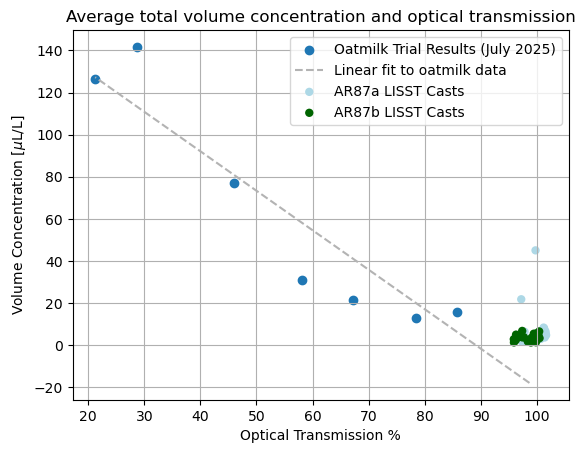

In [23]:
# Plot avg optical transmission against
# avg total volume concentration
fig0, ax0 = plt.subplots()
ax0.scatter(oat_optical_transmission_avg, oat_total_volume_avg, label="Oatmilk Trial Results (July 2025)")
ax0.plot(oat_optical_transmission_avg, estimate, "--", c="0.7", label="Linear fit to oatmilk data")
ax0.scatter(ar87a_optical_transmission_avg*100, ar87a_total_volume_avg, c="lightblue", edgecolors="none", label="AR87a LISST Casts")
ax0.scatter(ar87b_optical_transmission_avg*100, ar87b_total_volume_avg, c="darkgreen", edgecolors="none", label="AR87b LISST Casts")
ax0.set_xlabel("Optical Transmission %")
ax0.set_ylabel("Volume Concentration [$\mu$L/L]")
ax0.legend()
plt.title("Average total volume concentration and optical transmission")
ax0.grid()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kylene.cooley\AppData\Local\Temp\ipykernel_5820\622412261.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("Volume Concentration [$\mu$L/L]")


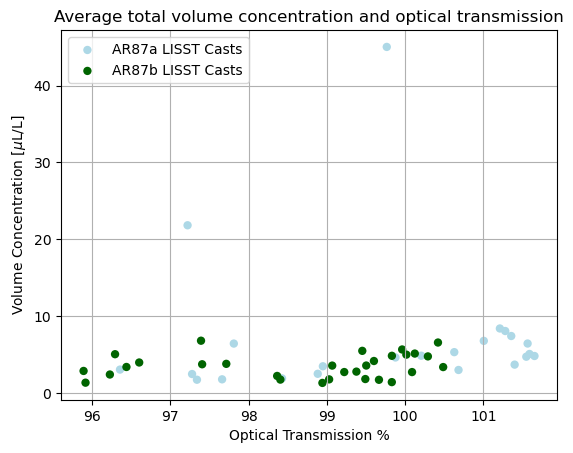

In [20]:
# Plot only Pioneer-21 LISST cast 
# avg optical transmission against
# avg total volume concentration
fig1, ax1 = plt.subplots()
ax1.scatter(ar87a_optical_transmission_avg*100, ar87a_total_volume_avg, c="lightblue", edgecolors="none", label="AR87a LISST Casts")
ax1.scatter(ar87b_optical_transmission_avg*100, ar87b_total_volume_avg, c="darkgreen", edgecolors="none", label="AR87b LISST Casts")
ax1.set_xlabel("Optical Transmission %")
ax1.set_ylabel("Volume Concentration [$\mu$L/L]")
ax1.legend()
plt.title("Average total volume concentration and optical transmission")
ax1.grid()